# run1_10peaks

MM PDEs against p. Each domain is sized by linear stability to hold 10 peaks of its
fastest-growing mode.

K=15, l=0.999, m=c=d=1, DN=1e-6, DI=1; p = 5 log-spaced values from 0.01 to 1, 10 reps each;
sN=2500, T=1e8. Every run starts from the analytic well-mixed steady state perturbed by
±1e-3 per gridpoint, clamped at 0.

In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()
using Statistics

## The runs

In [4]:
md = load("setup1.jld2", "metadata")
df = collect_pde_runs("main1")

@printf("%d runs, retcodes: %s\n", nrow(df), string(unique(string.(df.retcode))))
@printf("all reached T = %.3g: %s,  worst residual %.3g\n\n",
    md.T, all(df.final_T .== md.T), maximum(df.maxresid))

colors = Makie.resample_cmap(:viridis, length(md.ps))
DataFrame(;
    p=md.ps,
    peak_k=md.peak_ks,
    growth_rate=md.peak_hs,
    wavelength=2pi ./ md.peak_ks,
    L=md.Ls,
    dx=md.Ls ./ md.sN,
    init_peaks=num_peaks_in.(md.Ls, md.peak_ks),
)

50 runs, retcodes: ["Success"]
all reached T = 1e+08: true,  worst residual 7.03e-09



Row,p,peak_k,growth_rate,wavelength,L,dx,init_peaks
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.01,26.0016,0.0350024,0.241646,2.41646,0.000966585,10.0
2,0.0316228,22.0546,0.0213129,0.284892,2.84892,0.00113957,10.0
3,0.1,19.7697,0.0100416,0.317819,3.17819,0.00127128,10.0
4,0.316228,18.5994,0.00366515,0.337816,3.37816,0.00135126,10.0
5,1.0,17.7419,0.00101816,0.354144,3.54144,0.00141658,10.0


## 1. Dispersion relations

`fr3_disprel_simple` evaluated at the well-mixed steady state. The cross marks the peak each
domain size was taken from.

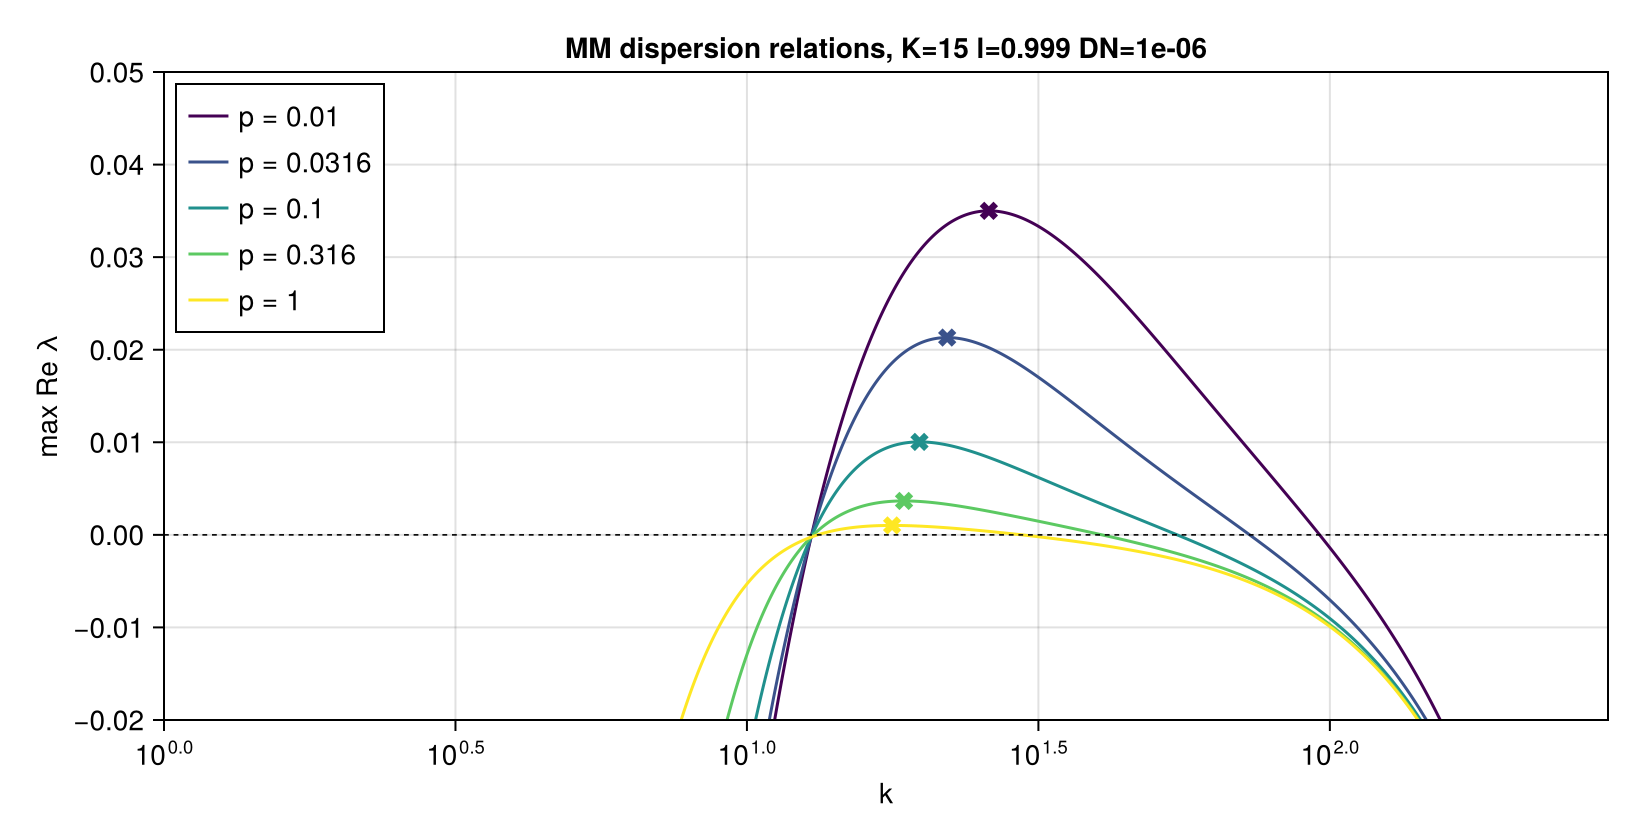

In [5]:
fig = Figure(; size=(820, 420))
ax = Axis(fig[1, 1]; xscale=log10, xlabel="k", ylabel="max Re λ",
    title=@sprintf("MM dispersion relations, K=%g l=%g DN=%g", md.K, md.l, md.DN))

for j in eachindex(md.ps)
    lines!(ax, md.ks, md.mrls[j]; color=colors[j], label=@sprintf("p = %.3g", md.ps[j]))
    scatter!(ax, [md.peak_ks[j]], [md.peak_hs[j]];
        color=colors[j], marker=:xcross, markersize=13)
end
hlines!(ax, 0.0; color=:black, linestyle=:dash, linewidth=0.8)

xlims!(ax, 1e0, 3e2)
ylims!(ax, -0.02, 0.05)
axislegend(ax; position=:lt)
fig

## 2. Time evolution

Kymographs of `N(x, t)`, one rep per p, log time axis, all panels over the shared `trange` set
at the top of the cell. Each time slice is normalised by its own maximum.

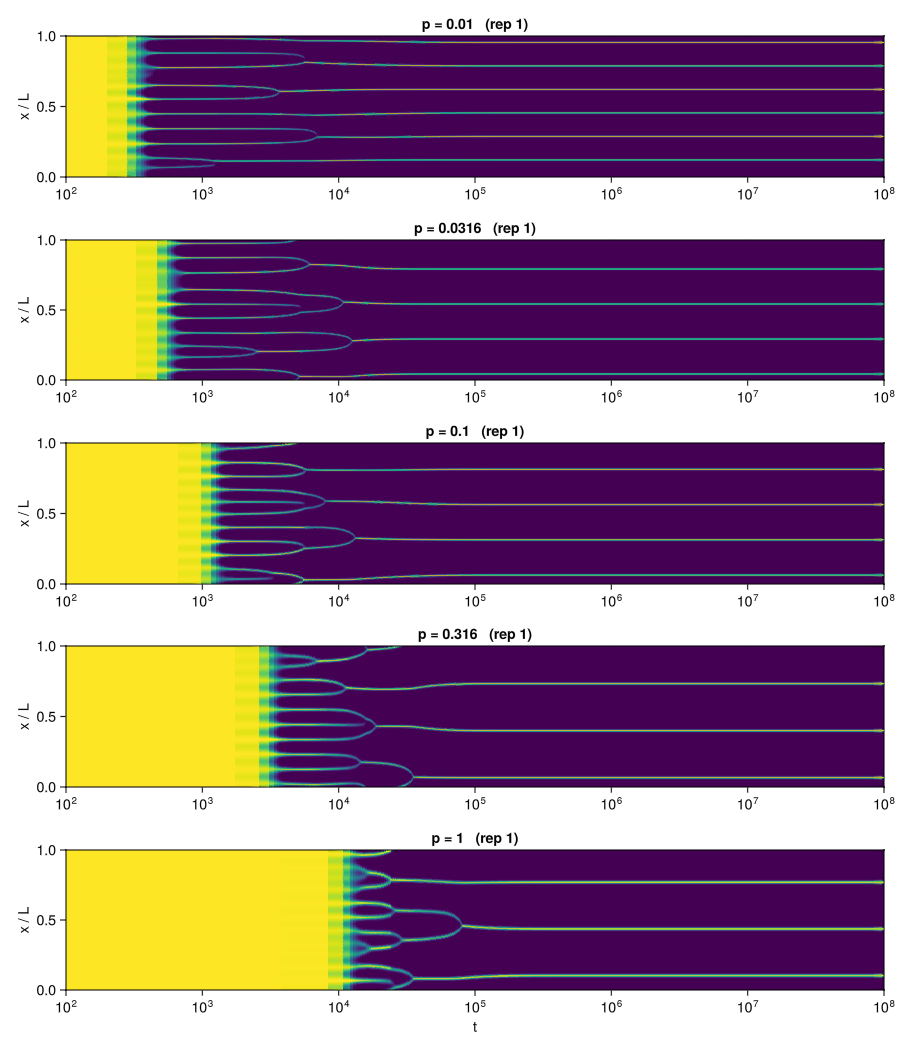

In [5]:
show_rep = 1

# The t window every panel is drawn over. Play with it - this is the whole point
# of the cell. Onset runs from t ~ 240 (p = 0.01) to t ~ 7600 (p = 1) and the last
# merge from ~1e4 to ~1e5, so (1e2, 1e6) holds every run's full story; narrow it
# to (1e3, 1e5) to zoom in on the merging.
trange = (1e2, 1e8)

"""
Cell edges for a heatmap on a log x axis. Makie builds edges from cell centres
by extrapolating half a cell past each end, which on these irregular solver
time grids lands below zero and makes log10 throw; bisecting in log space
instead keeps every edge positive.
"""
function log_edges(ts)
    lt = log10.(ts)
    mid = (lt[1:end-1] .+ lt[2:end]) ./ 2
    10 .^ vcat(2 * lt[1] - mid[1], mid, 2 * lt[end] - mid[end])
end

fig = Figure(; size=(900, 210 * length(md.ps)))
axs = map(eachindex(md.ps)) do j
    Axis(fig[j, 1]; xscale=log10, ylabel="x / L",
        title=@sprintf("p = %.3g   (rep %d)", md.ps[j], show_rep))
end
axs[end].xlabel = "t"

for j in eachindex(md.ps)
    r = only(eachrow(df[(df.p_i .== j) .& (df.rep .== show_rep), :]))
    (; ts, np, us_field) = peak_series("main1", r.pde_df_row; states=true)

    # the same window for every panel, so the rows are actually comparable and
    # linking the axes below does not crop anyone's data
    keep = findall(t -> trange[1] <= t <= trange[2], ts)
    if length(keep) < 2
        @warn "p = $(md.ps[j]) has $(length(keep)) saved states in trange, skipping"
        continue
    end

    # each time slice scaled by its own maximum. N grows from a 1e-3 ripple on
    # 12.9 to spikes of ~300, so on a shared colour scale the whole emergence
    # phase is one flat colour; per-slice normalisation shows the pattern's
    # shape at every stage, at the cost of saying nothing about amplitude.
    # Flat yellow is the homogeneous state, before this p's pattern has grown in.
    z = us_field[keep, :] ./ maximum(us_field[keep, :]; dims=2)

    xs = ((1:r.sN) .- 0.5) ./ r.sN     # x / L

    # stretch the outermost cells out to the window edges so the panel fills.
    # Honest here: outside the saved points the state is either still the
    # untouched initial condition (left) or the arrested one (right).
    edges = log_edges(ts[keep])
    edges[1], edges[end] = trange

    heatmap!(axs[j], edges, xs, z; colormap=:viridis, colorrange=(0, 1))
end

for ax2 in axs[2:end]
    linkaxes!(axs[1], ax2)
end
xlims!(axs[1], trange...)   # linked, so this sets every panel

GLMakie.activate!()
Makie.save("./kymos$show_rep.png", fig)

# display(GLMakie.Screen(), fig)
fig

## 3. Peak count over time

`count_peaks` on `N` at every saved state, all 50 runs. Dashed line is `min_peaks`.

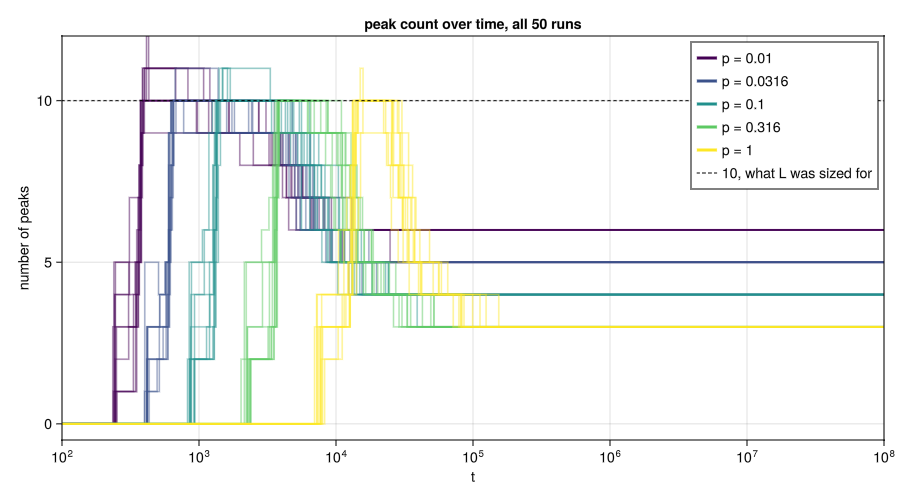

In [6]:
# Peak counts for every row. build_peak_cache("main1") writes these to a ~1MB
# file; without it this re-reads every saved state on each run.
series = peak_cache("main1")
if isnothing(series)
    @warn "no peak_cache - computing it now; run build_peak_cache(\"main1\") once to make this instant"
    series = Dict(i => peak_series("main1", i) for i in df.pde_df_row)
end

fig = Figure(; size=(900, 500))
ax = Axis(fig[1, 1]; xscale=log10, xlabel="t", ylabel="number of peaks",
    title="peak count over time, all 50 runs")

for j in eachindex(md.ps)
    for r in eachrow(df[df.p_i .== j, :])
        (; ts, np) = series[r.pde_df_row]
        keep = ts .> 0
        stairs!(ax, ts[keep], np[keep]; step=:post, color=(colors[j], 0.5))
    end
    # one opaque line per p for the legend
    lines!(ax, [NaN], [NaN]; color=colors[j], linewidth=3, label=@sprintf("p = %.3g", md.ps[j]))
end

hlines!(ax, md.min_peaks; color=:black, linestyle=:dash, linewidth=1,
    label=@sprintf("%d, what L was sized for", md.min_peaks))
xlims!(ax, 1e2, 1e8)
ylims!(ax, -0.5, 12)
axislegend(ax; position=:rt, framevisible=true)

Makie.save("numpeaks_vs_time.png", fig)
fig

## 4. Merge table

`merge_table`: peaks at onset (`max_np`) and at the end (`final_np`), when the pattern first
appeared (`t_first`), when the last merge happened (`t_last`), and `quiet`.

In [7]:
mt = merge_table("main1", df)

@printf("runs ending on a single peak: %d / %d\n", count(==(1), mt.final_np), nrow(mt))
@printf("final peak counts seen:       %s\n", string(sort(unique(mt.final_np))))
@printf("runs arrested (quiet):        %d / %d\n\n", count(mt.quiet), nrow(mt))

combine(groupby(mt, :p),
    :init_peaks => first => :sized_for,
    :max_np => (x -> @sprintf("%g - %g", minimum(x), maximum(x))) => :peaks_at_onset,
    :final_np => (x -> @sprintf("%g - %g", minimum(x), maximum(x))) => :final_peaks,
    :final_np => mean => :final_mean,
    :t_first => mean => :t_onset,
    :t_last => mean => :t_last_merge,
    :final_T => first => :t_end,
)

runs ending on a single peak: 0 / 50
final peak counts seen:       [3, 4, 5, 6]


runs arrested (quiet):        50 / 50



Row,p,sized_for,peaks_at_onset,final_peaks,final_mean,t_onset,t_last_merge,t_end
,Float64,Float64,String,String,Float64,Float64,Float64,Float64
1,0.01,10.0,9 - 12,5 - 6,5.7,243.304,10261.2,1.0e8
2,0.0316228,10.0,9 - 11,4 - 5,4.7,415.98,13000.7,1.0e8
3,0.1,10.0,10 - 11,3 - 4,3.9,878.708,19218.2,1.0e8
4,0.316228,10.0,9 - 10,3 - 3,3.0,2264.32,38247.9,1.0e8
5,1.0,10.0,9 - 11,3 - 3,3.0,7611.52,97370.3,1.0e8


### Counts and timescales

Left: onset and final peak counts per p, jittered horizontally. Right: `t_first` and `t_last`
against the end of the solve.

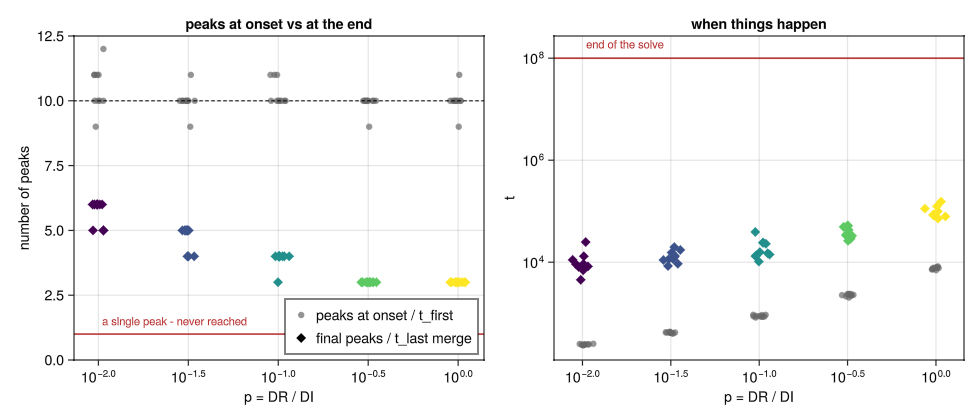

In [8]:
fig = Figure(; size=(980, 420))
axL = Axis(fig[1, 1]; xscale=log10, xlabel="p = DR / DI", ylabel="number of peaks",
    title="peaks at onset vs at the end")
axR = Axis(fig[1, 2]; xscale=log10, yscale=log10, xlabel="p = DR / DI", ylabel="t",
    title="when things happen")

jit(n, p) = p .* exp.(0.05 .* randn(n))

for j in eachindex(md.ps)
    sub = mt[mt.p .== md.ps[j], :]
    n = nrow(sub)
    scatter!(axL, jit(n, md.ps[j]), sub.max_np;
        color=(:grey40, 0.7), markersize=9, marker=:circle)
    scatter!(axL, jit(n, md.ps[j]), sub.final_np;
        color=colors[j], markersize=11, marker=:diamond)

    scatter!(axR, jit(n, md.ps[j]), sub.t_first; color=(:grey40, 0.7), markersize=9)
    scatter!(axR, jit(n, md.ps[j]), sub.t_last; color=colors[j], markersize=11, marker=:diamond)
end

hlines!(axL, md.min_peaks; color=:black, linestyle=:dash, linewidth=1)
hlines!(axL, 1.0; color=:firebrick, linewidth=1.5)
text!(axL, 1.05e-2, 1.25; text="a single peak - never reached", color=:firebrick, fontsize=11)
ylims!(axL, 0, 12.5)

hlines!(axR, md.T; color=:firebrick, linewidth=1.5)
text!(axR, 1.05e-2, 1.4e8; text="end of the solve", color=:firebrick, fontsize=11)

# legend proxies
scatter!(axL, [NaN], [NaN]; color=(:grey40, 0.7), markersize=9, label="peaks at onset / t_first")
scatter!(axL, [NaN], [NaN]; color=:black, markersize=11, marker=:diamond, label="final peaks / t_last merge")
axislegend(axL; position=:rb, framevisible=true)

fig

In [9]:
# How much longer each run sat still than it took to do all its merging
ratio = mt.final_T ./ mt.t_last
@printf("final_T / t_last_merge:  min %.3g,  median %.3g,  max %.3g\n",
    minimum(ratio), median(ratio), maximum(ratio))
@printf("every run held its final peak count for at least %.0fx the time it took to reach it\n",
    floor(minimum(ratio)))

final_T / t_last_merge:  min 648,  median 4.7e+03,  max 2.21e+04
every run held its final peak count for at least 648x the time it took to reach it


## 5. Final states

Final `N` profiles, one rep per p. Dashed line is the well-mixed steady state.

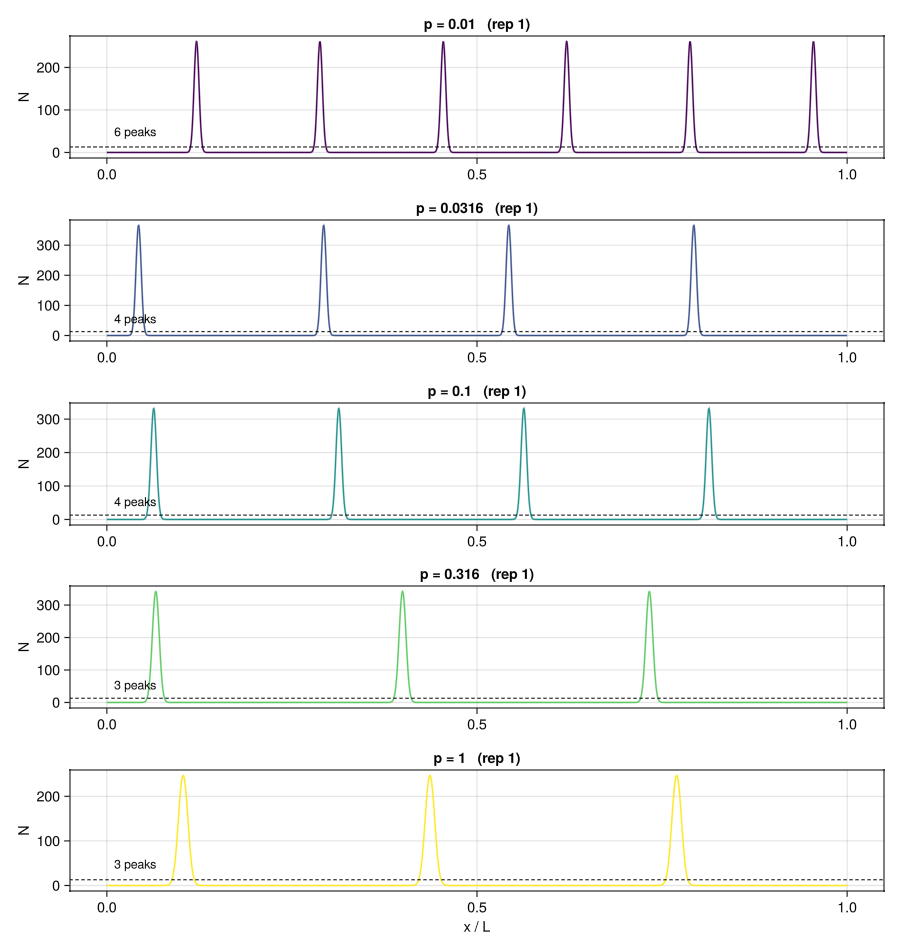

In [10]:
fig = Figure(; size=(900, 190 * length(md.ps)))
axs = map(eachindex(md.ps)) do j
    Axis(fig[j, 1]; ylabel="N", title=@sprintf("p = %.3g   (rep %d)", md.ps[j], show_rep))
end
axs[end].xlabel = "x / L"

for j in eachindex(md.ps)
    r = only(eachrow(df[(df.p_i .== j) .& (df.rep .== show_rep), :]))
    xs = ((1:r.sN) .- 0.5) ./ r.sN
    lines!(axs[j], xs, r.final_state[1, :]; color=colors[j])
    hlines!(axs[j], md.hss[1]; color=:black, linestyle=:dash, linewidth=1)
    text!(axs[j], 0.01, md.hss[1] * 2.5;
        text=@sprintf("%d peaks", count_peaks(r.final_state[1, :])), fontsize=12)
end

linkxaxes!(axs...)
fig